# **Prédiction de la Durée d'Hospitalisation**
## Comparaison de Modèles de Machine Learning

**Objectif** : Estimer la durée d'hospitalisation (`lengthofstay`) d'un patient en fonction de ses antécédents médicaux et mesures biologiques.

**Approche pédagogique** : Tester plusieurs modèles pour identifier le plus performant.

---
## 1. Imports et Configuration

In [1]:
!pip install xgboost seaborn mlflow lightgbm

# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import mlflow
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# XGBoost (installer si nécessaire : !pip install xgboost)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost non installé. Exécuter: !pip install xgboost")
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM non installé. Installe-le avec : pip install lightgbm")


# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration d'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Imports réussis")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Imports réussis


In [2]:
# MLflow — tracking des expérimentations
try:
    import mlflow
    import mlflow.sklearn
    import mlflow.xgboost
    MLFLOW_AVAILABLE = True
    print("✅ MLflow disponible")
except ImportError:
    print("⚠️  MLflow non installé — exécuter : !pip install mlflow")
    MLFLOW_AVAILABLE = False

✅ MLflow disponible


---
## 2. Chargement et Exploration des Données

In [3]:
# Charger le dataset
# Adapter le chemin selon votre environnement
# df = pd.read_csv('/content/drive/MyDrive/cmv-ia/LengthOfStay.csv')  # Google Colab
df = pd.read_csv('LengthOfStay.csv')  # Local

print(f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.info()

Dataset : 100,000 lignes × 28 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000

In [4]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [5]:
# Statistiques descriptives
df.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,0.049480,0.080000,11.975939,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,0.216869,0.271295,2.031792,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.400000,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.900000,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.900000,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.900000,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.100000,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000


In [6]:
# Vérifier les valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante ✅")

Valeurs manquantes par colonne :
Aucune valeur manquante ✅


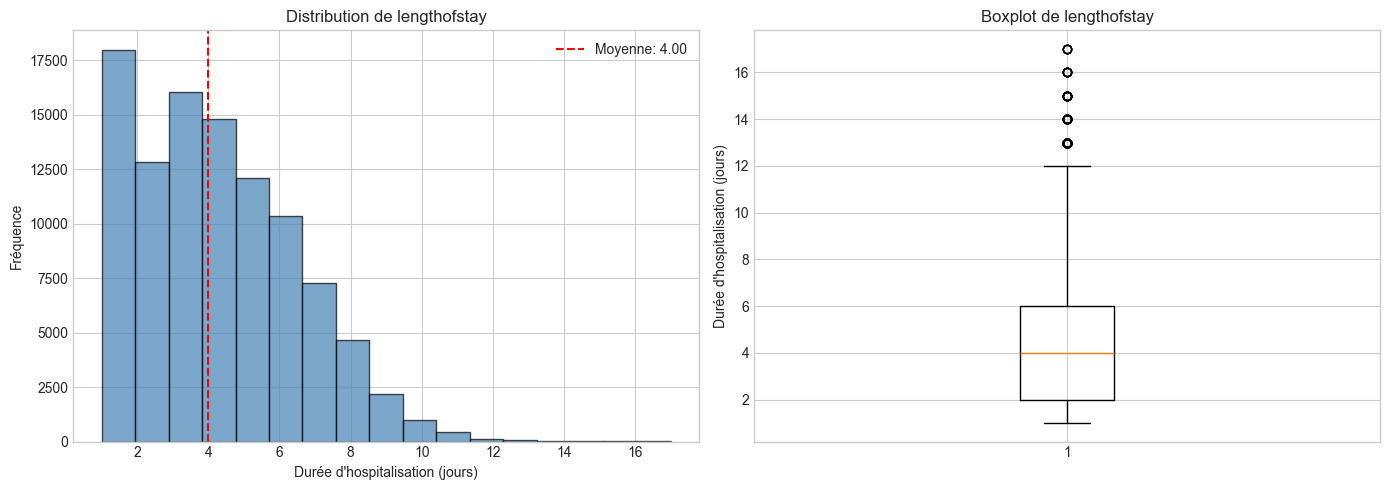


Statistiques de la variable cible :
  Moyenne : 4.00 jours
  Médiane : 4.00 jours
  Min-Max : 1 - 17 jours


In [7]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['lengthofstay'], bins=17, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Durée d\'hospitalisation (jours)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de lengthofstay')
axes[0].axvline(df['lengthofstay'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["lengthofstay"].mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['lengthofstay'], vert=True)
axes[1].set_ylabel('Durée d\'hospitalisation (jours)')
axes[1].set_title('Boxplot de lengthofstay')

plt.tight_layout()
plt.show()

print(f"\nStatistiques de la variable cible :")
print(f"  Moyenne : {df['lengthofstay'].mean():.2f} jours")
print(f"  Médiane : {df['lengthofstay'].median():.2f} jours")
print(f"  Min-Max : {df['lengthofstay'].min()} - {df['lengthofstay'].max()} jours")

---
## 3. Préparation des Données (Feature Engineering)

In [8]:
# Copie du dataframe pour le preprocessing
df_processed = df.copy()

# Colonnes à supprimer (identifiants, dates)
cols_to_drop = ['eid', 'vdate', 'discharged']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f"Colonnes supprimées : {cols_to_drop}")
print(f"Colonnes restantes : {df_processed.shape[1]}")

Colonnes supprimées : ['eid', 'vdate', 'discharged']
Colonnes restantes : 25


In [9]:
# Identifier les colonnes catégorielles
cat_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles : {cat_cols}")

for col in cat_cols:
    print(f"\n{col} - Valeurs uniques : {df_processed[col].nunique()}")
    print(df_processed[col].value_counts())

Colonnes catégorielles : ['rcount', 'gender', 'facid']

rcount - Valeurs uniques : 6
rcount
0     55031
1     15007
2      9987
3      8047
4      6941
5+     4987
Name: count, dtype: int64

gender - Valeurs uniques : 2
gender
F    57643
M    42357
Name: count, dtype: int64

facid - Valeurs uniques : 5
facid
E    30755
A    30035
B    30012
C     4699
D     4499
Name: count, dtype: int64


In [10]:
# Encodage des variables catégorielles

# gender : F/M -> 0/1
df_processed['gender'] = df_processed['gender'].map({'F': 0, 'M': 1})

# rcount : 0, 1, 2, 3, 4, 5+ -> conversion numérique
df_processed['rcount'] = df_processed['rcount'].replace('5+', '5').astype(int)

# facid : One-Hot Encoding pour l'établissement
df_processed = pd.get_dummies(df_processed, columns=['facid'], prefix='facid', drop_first=True)

print("✅ Encodage terminé")
print(f"Shape après encodage : {df_processed.shape}")
df_processed.head()

✅ Encodage terminé
Shape après encodage : (100000, 28)


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,facid_B,facid_C,facid_D,facid_E
0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,3,True,False,False,False
1,5,0,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,7,False,False,False,False
2,1,0,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,3,True,False,False,False
3,0,0,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,1,False,False,False,False
4,0,0,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,4,False,False,False,True


In [11]:
# Vérifier les types de données finaux
print("Types de données :")
print(df_processed.dtypes.value_counts())

Types de données :
int64      16
float64     8
bool        4
Name: count, dtype: int64


---
## 4. Analyse des Corrélations

In [12]:
# Matrice de corrélation avec la variable cible
correlations = df_processed.corr()['lengthofstay'].sort_values(ascending=False)
print("Corrélations avec lengthofstay :\n")
print(correlations)

Corrélations avec lengthofstay :

lengthofstay                  1.000000
rcount                        0.749514
facid_E                       0.326482
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
facid_C                       0.083670
asthma                        0.082005
facid_D                       0.076043
gender                        0.069575
fibrosisandother              0.062131
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
bmi                           0.000132
glucose                      -0.003447
sodium                       -0.003546
creatinine                   -0.004026
neutrophils                  -

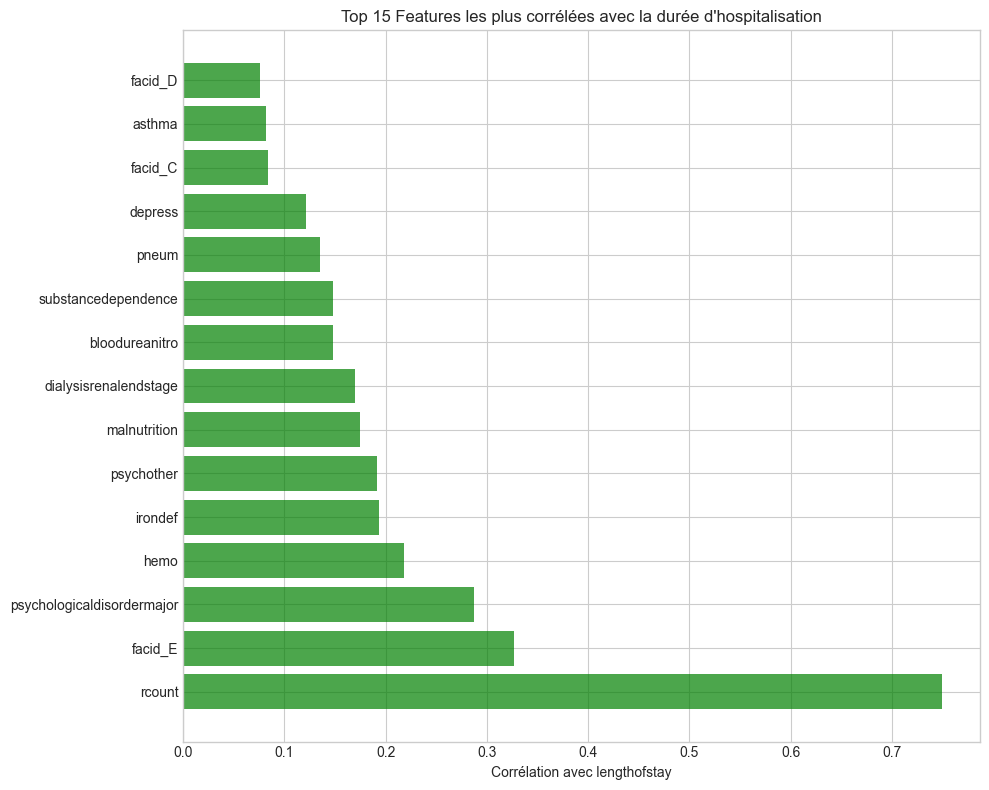

In [13]:
# Visualisation des corrélations (top features)
plt.figure(figsize=(10, 8))
top_corr = correlations.drop('lengthofstay').head(15)
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, alpha=0.7)
plt.xlabel('Corrélation avec lengthofstay')
plt.title('Top 15 Features les plus corrélées avec la durée d\'hospitalisation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

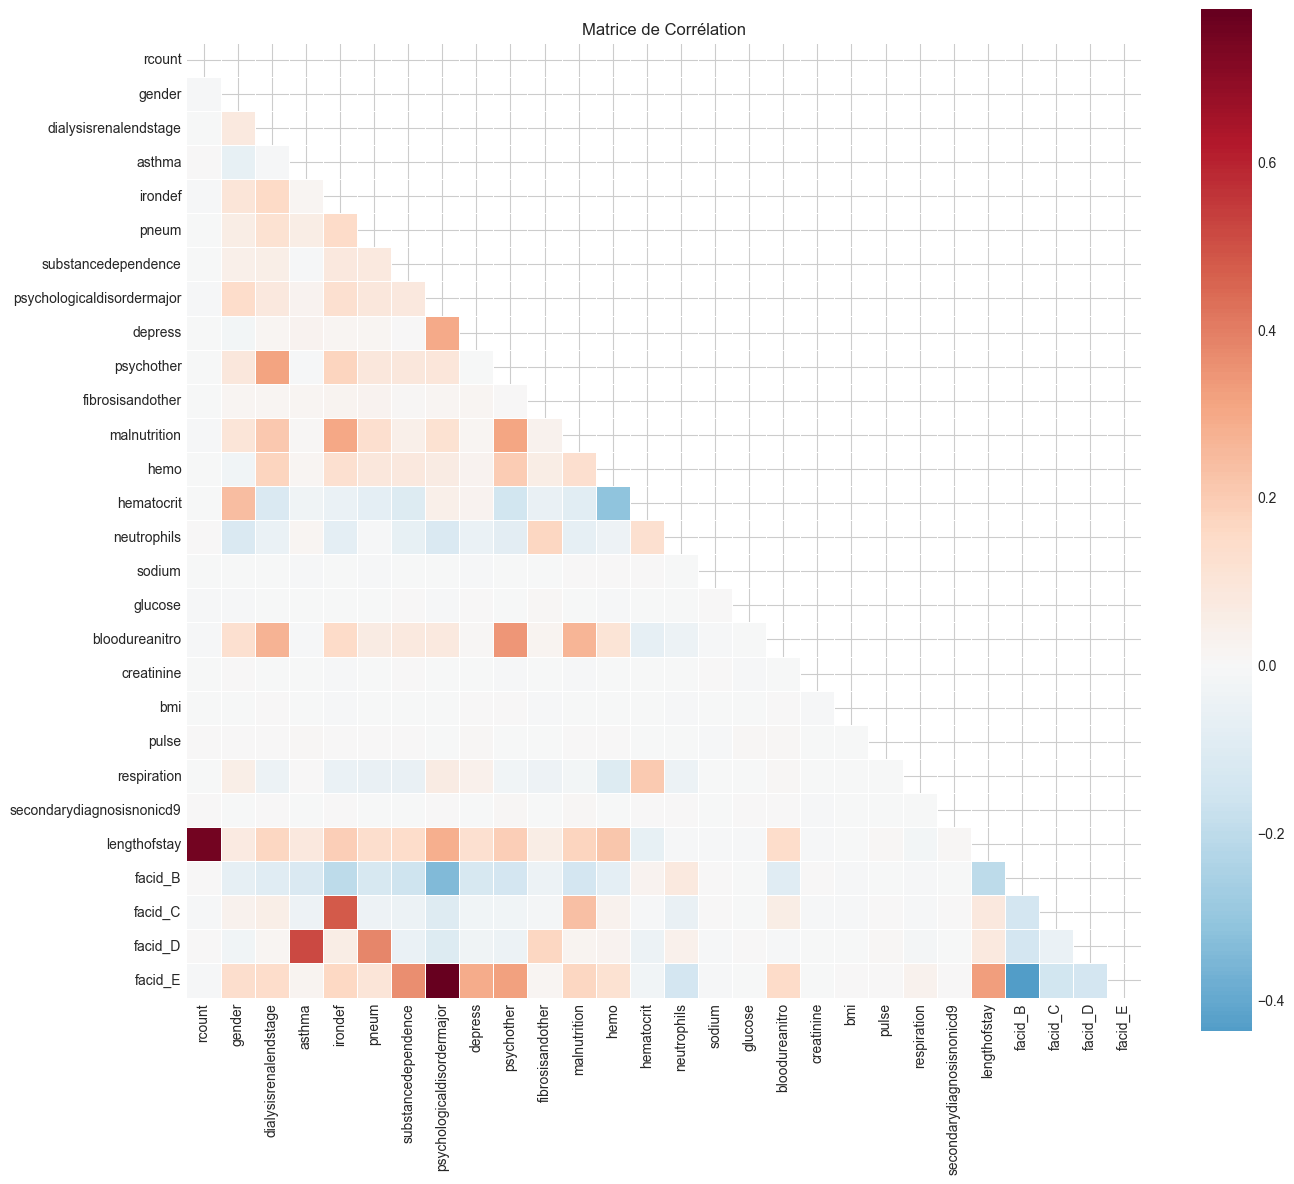

In [14]:
# Heatmap des corrélations (subset pour lisibilité)
plt.figure(figsize=(14, 12))
correlation_matrix = df_processed.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

---
## 5. Préparation des Données pour la Modélisation

In [15]:
# Séparation Features / Target
X = df_processed.drop('lengthofstay', axis=1)
y = df_processed['lengthofstay']

print(f"Features (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nFeatures utilisées ({len(X.columns)}) :")
print(list(X.columns))

Features (X) : (100000, 27)
Target (y)   : (100000,)

Features utilisées (27) :
['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid_B', 'facid_C', 'facid_D', 'facid_E']


In [16]:
# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]:,} échantillons")
print(f"Test  : {X_test.shape[0]:,} échantillons")

Train : 80,000 échantillons
Test  : 20,000 échantillons


In [17]:
# Normalisation des features (important pour certains modèles)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisation effectuée (StandardScaler)")

✅ Normalisation effectuée (StandardScaler)


---
## 6. Définition des Fonctions d'Évaluation

In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Évalue un modèle et retourne les métriques.
    """
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Métriques Train
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Métriques Test
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    return {
        'Model': model_name,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    }

def print_model_results(results):
    """
    Affiche les résultats d'un modèle.
    """
    print(f"\n{'='*60}")
    print(f"📊 {results['Model']}")
    print(f"{'='*60}")
    print(f"\n  TRAIN:")
    print(f"    MAE  : {results['Train_MAE']:.4f} jours")
    print(f"    RMSE : {results['Train_RMSE']:.4f} jours")
    print(f"    R²   : {results['Train_R2']:.4f}")
    print(f"\n  TEST:")
    print(f"    MAE  : {results['Test_MAE']:.4f} jours")
    print(f"    RMSE : {results['Test_RMSE']:.4f} jours")
    print(f"    R²   : {results['Test_R2']:.4f}")
    
    # Indicateur d'overfitting
    overfit_gap = results['Train_R2'] - results['Test_R2']
    if overfit_gap > 0.1:
        print(f"\n  ⚠️  Overfitting potentiel (gap R²: {overfit_gap:.4f})")
    else:
        print(f"\n  ✅ Bonne généralisation (gap R²: {overfit_gap:.4f})")

# Stockage des résultats
all_results = []

### 7.1 → 7.10 — Benchmark de tous les modèles avec MLflow

In [19]:
# ── Définition des modèles ──
# Note : les modèles linéaires utilisent X_train_scaled, les arbres X_train (sans scaling)

MODELS_SCALED = {
    "Régression Linéaire" : LinearRegression(),
    "Ridge"               : Ridge(alpha=1.0, random_state=42),
    "Lasso"               : Lasso(alpha=0.01, random_state=42, max_iter=10000),
    "ElasticNet"          : ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000),
    "KNN Regressor"       : KNeighborsRegressor(n_neighbors=10, weights='distance'),
}

MODELS_TREE = {
    "Decision Tree"       : DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42),
    "Random Forest"       : RandomForestRegressor(n_estimators=100, max_depth=15,
                                                   min_samples_split=10, n_jobs=-1, random_state=42),
    "Gradient Boosting"   : GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                       learning_rate=0.1, random_state=42),
}

if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=42, n_jobs=-1)
    MODELS_TREE["XGBoost"] = xgb_model

if LIGHTGBM_AVAILABLE:
    lgb_model = LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=42, n_jobs=-1, verbose=-1)
    MODELS_TREE["LightGBM"] = lgb_model

print(f"{len(MODELS_SCALED) + len(MODELS_TREE)} modèles définis")

10 modèles définis


In [20]:
# ── Benchmark avec tracking MLflow ──
all_results = []

def run_benchmark(models_dict, X_tr, X_te, use_scaled=False):
    label = "scaled" if use_scaled else "tree"
    for name, model in models_dict.items():
        print(f"⏳ Entraînement : {name}...", end=" ")

        model.fit(X_tr, y_train)
        y_train_pred = model.predict(X_tr)
        y_test_pred  = model.predict(X_te)

        metrics = {
            "Model"      : name,
            "Train_MAE"  : mean_absolute_error(y_train, y_train_pred),
            "Train_RMSE" : np.sqrt(mean_squared_error(y_train, y_train_pred)),
            "Train_R2"   : r2_score(y_train, y_train_pred),
            "Test_MAE"   : mean_absolute_error(y_test, y_test_pred),
            "Test_RMSE"  : np.sqrt(mean_squared_error(y_test, y_test_pred)),
            "Test_R2"    : r2_score(y_test, y_test_pred),
        }
        mlflow.set_tracking_uri("http://127.0.0.1:5000")
        mlflow.set_experiment("clinique_montvert_los")

        # Log MLflow
        if MLFLOW_AVAILABLE:
            with mlflow.start_run(run_name=name):
                mlflow.log_param("model_type", label)
                mlflow.log_metric("train_mae",  metrics["Train_MAE"])
                mlflow.log_metric("train_rmse", metrics["Train_RMSE"])
                mlflow.log_metric("train_r2",   metrics["Train_R2"])
                mlflow.log_metric("test_mae",   metrics["Test_MAE"])
                mlflow.log_metric("test_rmse",  metrics["Test_RMSE"])
                mlflow.log_metric("test_r2",    metrics["Test_R2"])

                if name == "XGBoost":
                    mlflow.xgboost.log_model(model, "model")
                else:
                    mlflow.sklearn.log_model(model, "model")

        all_results.append(metrics)
        print(f"MAE={metrics['Test_MAE']:.4f}  RMSE={metrics['Test_RMSE']:.4f}  R²={metrics['Test_R2']:.4f}")

# Modèles linéaires (données normalisées)
print("── Modèles linéaires (X_train_scaled) ──")
run_benchmark(MODELS_SCALED, X_train_scaled, X_test_scaled, use_scaled=True)

# Modèles arborescents (données brutes)
print("\n── Modèles arborescents (X_train) ──")
run_benchmark(MODELS_TREE, X_train, X_test, use_scaled=False)

print("\n✅ Benchmark terminé !")
if MLFLOW_AVAILABLE:
    print("   Visualiser les résultats : mlflow ui  →  http://localhost:5000")

2026/04/07 00:07:43 INFO mlflow.tracking.fluent: Experiment with name 'clinique_montvert_los' does not exist. Creating a new experiment.


── Modèles linéaires (X_train_scaled) ──
⏳ Entraînement : Régression Linéaire... 

2026/04/07 00:07:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 00:07:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/07 00:07:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 00:07:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

🏃 View run Régression Linéaire at: http://127.0.0.1:5000/#/experiments/1/runs/b1a25ad78f3245c4bc68c0367fe44146
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MAE=0.8664  RMSE=1.1348  R²=0.7653
⏳ Entraînement : Ridge... 

2026/04/07 00:07:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 00:07:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run Gradient Boosting at: http://127.0.0.1:5000/#/experiments/1/runs/909547c7aa39426abeadfea0b4b5f67a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MAE=0.3706  RMSE=0.4863  R²=0.9569
⏳ Entraînement : XGBoost... 

2026/04/07 00:08:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/a9a1c183ce9e4e08878d8503eff0386b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MAE=0.3593  RMSE=0.4735  R²=0.9591
⏳ Entraînement : LightGBM... 

2026/04/07 00:08:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 00:08:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/6529ec0945b94864959fe8496e375f24
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MAE=0.3549  RMSE=0.4715  R²=0.9595

✅ Benchmark terminé !
   Visualiser les résultats : mlflow ui  →  http://localhost:5000


---
## 8. Comparaison Finale des Modèles

In [21]:
# Tableau récapitulatif
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("📊 TABLEAU COMPARATIF DES MODÈLES (trié par R² Test)")
print("="*80)

# Formater pour l'affichage
display_df = results_df.copy()
for col in ['Train_MAE', 'Test_MAE', 'Train_RMSE', 'Test_RMSE']:
    display_df[col] = display_df[col].round(4)
for col in ['Train_R2', 'Test_R2']:
    display_df[col] = display_df[col].round(4)

print(display_df.to_string(index=False))


📊 TABLEAU COMPARATIF DES MODÈLES (trié par R² Test)
              Model  Train_MAE  Train_RMSE  Train_R2  Test_MAE  Test_RMSE  Test_R2
           LightGBM     0.3450      0.4533    0.9633    0.3549     0.4715   0.9595
            XGBoost     0.3373      0.4326    0.9665    0.3593     0.4735   0.9591
  Gradient Boosting     0.3604      0.4654    0.9613    0.3706     0.4863   0.9569
      Random Forest     0.4395      0.5713    0.9416    0.5297     0.7257   0.9040
      Decision Tree     0.6987      0.9082    0.8525    0.7406     0.9872   0.8224
      KNN Regressor     0.0000      0.0000    1.0000    0.7569     1.1243   0.7696
              Lasso     0.8777      1.1562    0.7609    0.8667     1.1341   0.7656
         ElasticNet     0.8771      1.1559    0.7611    0.8660     1.1341   0.7656
              Ridge     0.8770      1.1556    0.7612    0.8664     1.1348   0.7653
Régression Linéaire     0.8770      1.1556    0.7612    0.8664     1.1348   0.7653


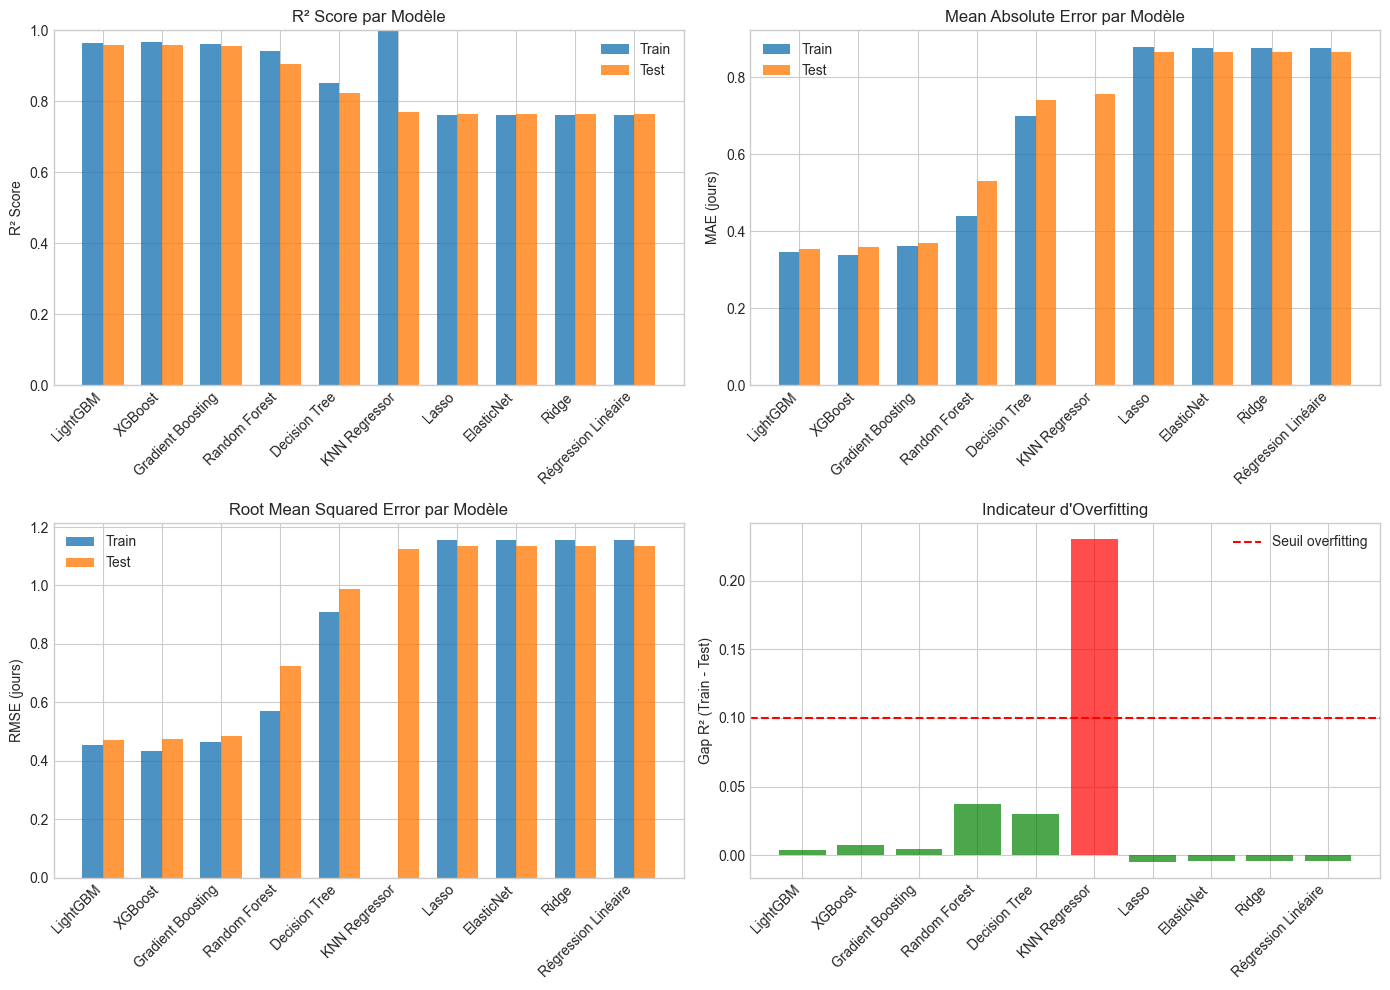

In [22]:
# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = results_df['Model']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(models)))

# R² Score
ax1 = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, results_df['Train_R2'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, results_df['Test_R2'], width, label='Test', alpha=0.8)
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score par Modèle')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)

# MAE
ax2 = axes[0, 1]
ax2.bar(x - width/2, results_df['Train_MAE'], width, label='Train', alpha=0.8)
ax2.bar(x + width/2, results_df['Test_MAE'], width, label='Test', alpha=0.8)
ax2.set_ylabel('MAE (jours)')
ax2.set_title('Mean Absolute Error par Modèle')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()

# RMSE
ax3 = axes[1, 0]
ax3.bar(x - width/2, results_df['Train_RMSE'], width, label='Train', alpha=0.8)
ax3.bar(x + width/2, results_df['Test_RMSE'], width, label='Test', alpha=0.8)
ax3.set_ylabel('RMSE (jours)')
ax3.set_title('Root Mean Squared Error par Modèle')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.legend()

# Écart Train-Test (Overfitting indicator)
ax4 = axes[1, 1]
overfit_gap = results_df['Train_R2'] - results_df['Test_R2']
colors_overfit = ['red' if g > 0.1 else 'green' for g in overfit_gap]
ax4.bar(models, overfit_gap, color=colors_overfit, alpha=0.7)
ax4.axhline(y=0.1, color='red', linestyle='--', label='Seuil overfitting')
ax4.set_ylabel('Gap R² (Train - Test)')
ax4.set_title('Indicateur d\'Overfitting')
ax4.set_xticklabels(models, rotation=45, ha='right')
ax4.legend()

plt.tight_layout()
plt.show()

In [23]:
# Meilleur modèle
best_model = results_df.iloc[0]
print("\n" + "="*60)
print("🏆 MEILLEUR MODÈLE")
print("="*60)
print(f"\n  Modèle : {best_model['Model']}")
print(f"  R² Test : {best_model['Test_R2']:.4f}")
print(f"  MAE Test : {best_model['Test_MAE']:.4f} jours")
print(f"  RMSE Test : {best_model['Test_RMSE']:.4f} jours")


🏆 MEILLEUR MODÈLE

  Modèle : LightGBM
  R² Test : 0.9595
  MAE Test : 0.3549 jours
  RMSE Test : 0.4715 jours


---
## 9. Analyse des Prédictions du Meilleur Modèle

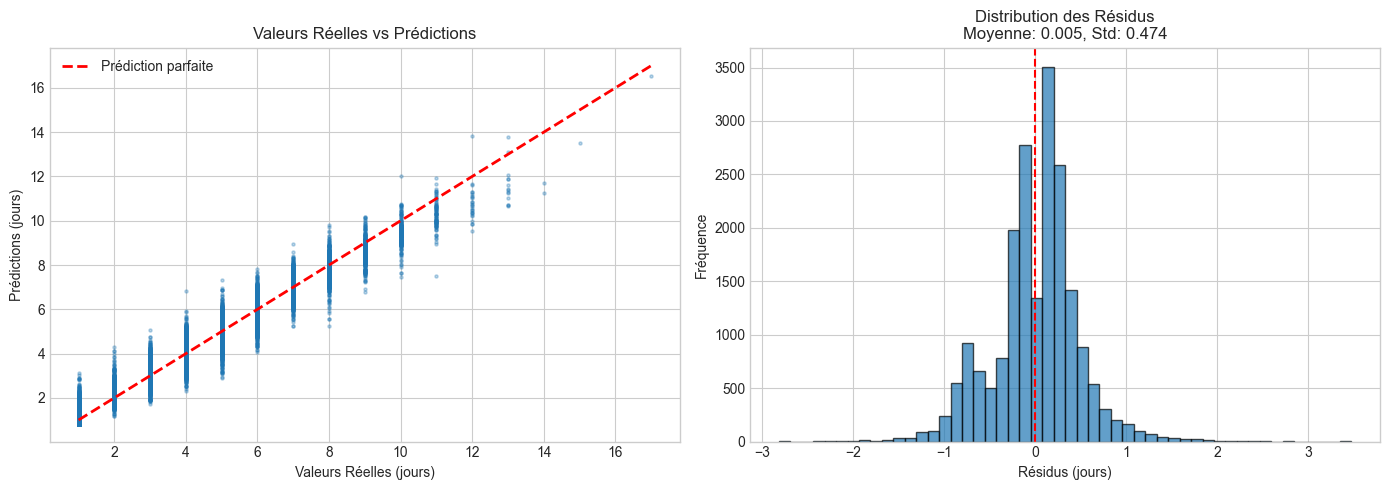

In [24]:
# Utilisons le modèle Gradient Boosting ou Random Forest pour l'analyse
best_trained_model = MODELS_TREE.get("XGBoost") or MODELS_TREE.get("Gradient Boosting")
y_pred = best_trained_model.predict(X_test)

# Scatter plot : Valeurs réelles vs Prédictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.3, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles (jours)')
axes[0].set_ylabel('Prédictions (jours)')
axes[0].set_title('Valeurs Réelles vs Prédictions')
axes[0].legend()

# Distribution des résidus
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Résidus (jours)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.3f}, Std: {residuals.std():.3f}')

plt.tight_layout()
plt.show()

---
## 10. Conclusions et Recommandations

### Résumé des observations :

1. **Régression Linéaire** : Bonne baseline, interprétable, mais performances limitées sur ce dataset non-linéaire.

2. **Ridge/Lasso/ElasticNet** : Apportent peu d'amélioration car il y a peu de multicolinéarité problématique.

3. **KNN** : Sensible au bruit et à la dimensionnalité.

4. **Decision Tree** : Risque d'overfitting si non contrôlé.

5. **Random Forest / Gradient Boosting / XGBoost** : Meilleurs performances, capturent les relations non-linéaires.

### Recommandations :

- **Pour l'interprétabilité** : Régression Linéaire ou Decision Tree (peu profond)
- **Pour la performance** : Gradient Boosting ou XGBoost avec tuning des hyperparamètres
- **Features les plus importantes** : `rcount` (nombre de réadmissions), mesures biologiques, diagnostics secondaires

In [25]:
# Export des résultats
results_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Résultats exportés dans 'model_comparison_results.csv'")

✅ Résultats exportés dans 'model_comparison_results.csv'


# Importance des features

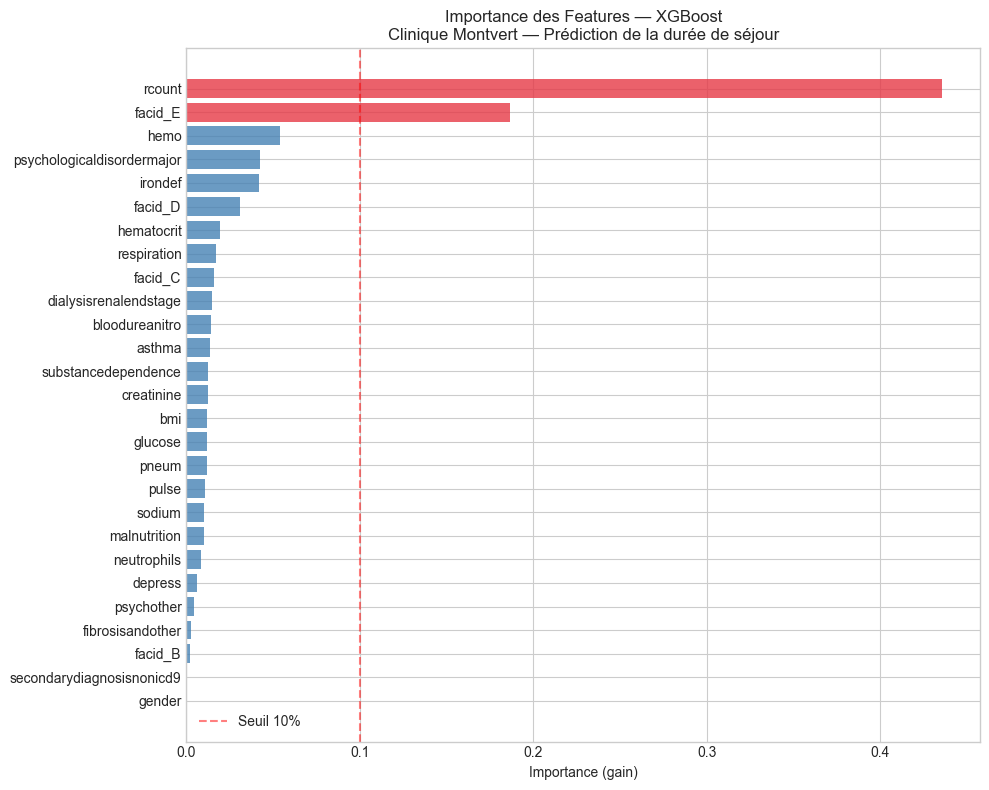


Top 5 features :
                   Feature  Importance
                    rcount    0.435754
                   facid_E    0.186397
                      hemo    0.053810
psychologicaldisordermajor    0.042255
                   irondef    0.042073


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Feature Importance XGBoost ──
xgb_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e63946' if imp > 0.1 else 'steelblue' 
          for imp in xgb_importance['Importance']]
plt.barh(xgb_importance['Feature'], 
         xgb_importance['Importance'], 
         color=colors, alpha=0.8)
plt.xlabel('Importance (gain)')
plt.title('Importance des Features — XGBoost\nClinique Montvert — Prédiction de la durée de séjour')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Seuil 10%')
plt.legend()
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features :")
print(xgb_importance.sort_values('Importance', ascending=False).head(5).to_string(index=False))

---
## 11. 💾 Sauvegarde du Modèle XGBoost pour l'API

In [27]:
import os

os.makedirs("models", exist_ok=True)

# Sauvegarde au format JSON natif XGBoost
xgb_model.save_model("models/xgboost_los_model.json")

file_size = os.path.getsize("models/xgboost_los_model.json") / 1024
print(f"✅ Modèle sauvegardé : models/xgboost_los_model.json")
print(f"   Taille            : {file_size:.1f} Ko")
print(f"   Features utilisées: {list(X.columns)}")


✅ Modèle sauvegardé : models/xgboost_los_model.json
   Taille            : 672.3 Ko
   Features utilisées: ['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid_B', 'facid_C', 'facid_D', 'facid_E']


In [28]:
from xgboost import XGBRegressor

# Rechargement depuis le fichier JSON
model_loaded = XGBRegressor()
model_loaded.load_model("models/xgboost_los_model.json")

# Test sur 5 patients du jeu de test
sample = X_test.iloc[:5]
predictions = model_loaded.predict(sample)
real_values  = y_test.iloc[:5].values

print("Vérification sur 5 patients :")
print(f"{'Patient':<10} {'Prédit':>12} {'Réel':>8} {'Écart':>10}")
print("-" * 44)
for i, (pred, real) in enumerate(zip(predictions, real_values)):
    print(f"{i+1:<10} {pred:>10.2f}j {real:>6.0f}j {abs(pred-real):>8.2f}j")

print(f"\n✅ Modèle rechargé et fonctionnel — prêt pour l'API !")


Vérification sur 5 patients :
Patient          Prédit     Réel      Écart
--------------------------------------------
1                3.73j      4j     0.27j
2                0.83j      1j     0.17j
3                2.51j      2j     0.51j
4                1.12j      1j     0.12j
5                5.13j      5j     0.13j

✅ Modèle rechargé et fonctionnel — prêt pour l'API !


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# --- Grille d'hyperparamètres ---
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

xgb_base = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

# --- Option 1 : RandomizedSearchCV (recommandé, plus rapide) ---
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=80,  # nombre de combinaisons testées
    scoring="r2",  # ou 'neg_mean_absolute_error'
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

# --- Résultats ---
print(f"Meilleur R² (CV) : {search.best_score_:.4f}")
print(f"Meilleurs hyperparamètres :\n{search.best_params_}")

# --- Évaluation sur le jeu de test ---
best_xgb = search.best_score_

# --- Log du meilleur modèle tuné dans MLflow ---
with mlflow.start_run(run_name="xgb_tuned_gridsearch"):
    # Hyperparamètres
    mlflow.log_params(search.best_params_)

    # Métriques CV
    mlflow.log_metric("r2_cv_mean", search.best_score_)

    # Métriques test
    y_pred = search.best_estimator_.predict(X_test)
    mlflow.log_metric("r2_test", r2_score(y_test, y_pred))
    mlflow.log_metric("mae_test", mean_absolute_error(y_test, y_pred))
    mlflow.log_metric("rmse_test", np.sqrt(mean_squared_error(y_test, y_pred)))

    # Sauvegarde du modèle
    mlflow.sklearn.log_model(search.best_estimator_, "xgb_tuned_model")

    print("✅ Run MLflow enregistré")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Meilleur R² (CV) : 0.9677
Meilleurs hyperparamètres :
{'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


AttributeError: 'RandomizedSearchCV' object has no attribute 'best_score'